<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.4-training-building-a-cnn-mfccs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU).

En este notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, es decir los canales correspondientes al delta del mel-spec y a espectrograma *cohclear db*.

Cabe destacar que, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra arquitectura posee la siguiente estructura base:

## Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1.0 Imports y configuración base


In [28]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,f1_score, accuracy_score)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [29]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

True

In [30]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 1.2 Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [31]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors_mfcc /content/split_pytorch_tensors

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 13, 51)


### 1.3 Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [33]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mfcc, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (13x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=3), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=1)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (MFCC, Delta, Delta2)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)

      return x, y

### 1.4 Configuracion Early Stop

In [34]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


### 1.5 Dataloaders

In [35]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 1.6 Definición de la CGRU


In [46]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        # Entrada esperada: (Batch, 3, 13, 51)
        self.cnn = nn.Sequential(
            # Bloque Convolucional 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Reducimos frecuencia suavemente, mantenemos tiempo intacto
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 13 -> 6, Tiempo: 51 -> 51

            # Bloque Convolucional 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 6 -> 3, Tiempo: 51 -> 51
            nn.Dropout2d(0.25),

            # Bloque Convolucional 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.25)
            # Salida de CNN: (Batch, 64, 3, 51)
        )

        # 64 canales * 3 bins de frecuencia restantes = 192 features por frame
        self.gru_input_size = 64 * 3

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=64,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.25
        )

        self.classifier = nn.Sequential(
            # 64 * 2 porque la GRU es bidireccional
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(classifier_dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # 1. Extracción de características CNN
        x = self.cnn(x)

        batch_size, channels, freq, time = x.size()

        # 2. Formatear para GRU: (Batch, Tiempo, Features)
        # Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 64, 3)
        x = x.permute(0, 3, 1, 2).contiguous()
        # Aplanamos a (Batch, 51, 192)
        x = x.view(batch_size, time, channels * freq)

        # 3. Modelado Secuencial
        gru_out, _ = self.bigru(x)

        # 4. Pooling temporal (promedio) y clasificación
        x = gru_out.mean(dim=1)
        return self.classifier(x)

## Tracking con Weights & Biases (W&B)

En los cuadernos de Colab/Jupyter, volver a ejecutar las celdas a menudo sobrescribe variables y resultados, lo que facilita la pérdida de:

* Qué hiperparámetros produjeron el mejor modelo y
las curvas de entrenamiento completas (pérdida/F1 vs. época).

* El mejor punto de control para esa ejecución, la matriz de confusión y
informe de clasificación asociado a ese punto de control.

***W&B*** soluciona esto almacenando las ejecuciones en un registro de experimentos externo, donde cada ejecución incluye:

1. Aspectos de la configuración `(wandb.config)` como por ejemplo: `dropout`,`seeds`,`weight decay`,`Learnig rate`, etc.

2. La serie temporal de métricas por época `train val loss`, `macro-F1`, `LR`.

3. Artefactos como puntos de control del modelo e informes.

### 2.0 Configuración de W&B

El baseline se contruye a partir de experimentacion anterior donde se obtuvo mayor estabilidad con un `BATCH_SIZE=32`, y como mencionamos antes sin *online data augmentation*, aunque se conservan estas funcionalidades con motivos investigativos, para futuros usuarios.

In [37]:
# --- Configuración de W&B y matriz de experimentos -----------------------------

# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado con API key.
USE_WANDB      = True                # ← cambiar a True para activar tracking
WANDB_PROJECT  = "tcoe-experiments-aug-and-drop-mfccs"
WANDB_GROUP    = "cnn-cgru-batch32-2.1"  # agrupa los cuatro experimentos en la misma vista (Mul útil)

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------

# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por ejecucion
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.

RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [38]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.896268566598237, 0.896268566598237, 0.896268566598237, 0.896268566598237, 0.9647731704146627, 0.896268566598237, 2.5987394957983194]



  INICIANDO: run1_lr3e4_wd1e3_do05_cw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=True



[21:06:29] Epoca 01/50 | Train loss 2.0853 acc 0.1489 | Val loss 1.9067 acc 0.2404 f1 0.1419 | lr 3.0e-04 | Time 6.5s


[21:06:36] Epoca 02/50 | Train loss 1.9657 acc 0.1851 | Val loss 1.8697 acc 0.2464 f1 0.1613 | lr 3.0e-04 | Time 6.3s


[21:06:43] Epoca 03/50 | Train loss 1.8949 acc 0.2286 | Val loss 1.8259 acc 0.2847 f1 0.2082 | lr 3.0e-04 | Time 7.2s


[21:06:49] Epoca 04/50 | Train loss 1.8401 acc 0.2425 | Val loss 1.8106 acc 0.2919 f1 0.2328 | lr 3.0e-04 | Time 6.0s


...

[21:07:58] Epoca 14/50 | Train loss 1.6760 acc 0.3358 | Val loss 1.6848 acc 0.3373 f1 0.2962 | lr 7.5e-05 | Time 7.3s
Early Stopping: 4/8 (best=0.3041)


[21:08:04] Epoca 15/50 | Train loss 1.6644 acc 0.3343 | Val loss 1.6691 acc 0.3373 f1 0.2896 | lr 7.5e-05 | Time 5.9s
Early Stopping: 5/8 (best=0.3041)


[21:08:10] Epoca 16/50 | Train loss 1.6622 acc 0.3387 | Val loss 1.6762 acc 0.3385 f1 0.2929 | lr 3.7e-05 | Time 6.6s
Early Stopping: 6/8 (best=0.3041)


[21:08:17] Epoca 17/50 | Train loss 1.6647 acc 0.3436 | Val loss 1.6616 acc 0.3481 f1 0.3033 | lr 3.7e-05 | Time 6.5s
Early Stopping: 7/8 (best=0.3041)


[21:08:23] Epoca 18/50 | Train loss 1.6516 acc 0.3434 | Val loss 1.6733 acc 0.3385 f1 0.2965 | lr 3.7e-05 | Time 6.1s
Early Stopping: 8/8 (best=0.3041)
Early stopping en epoch 18 (best val_f1=0.3041)

--- RESULTADO TEST [run1_lr3e4_wd1e3_do05_cw] ---
  best_epoch=10  best_val_f1=0.3041
  test_macro_f1=0.2892  test_acc=0.3382
              precision    recall  f1-score   support

       angry       0.39      0.66      0.49       144
     disgust       0.32      0.10      0.16       144
     fearful       0.50      0.03      0.06       144
       happy       0.29      0.11      0.16       144
     neutral       0.41      0.35      0.37       144
         sad       0.45      0.63      0.53       144
   surprised       0.14      0.97      0.25        32

    accuracy                           0.34       896
   macro avg       0.36      0.41      0.29       896
weighted avg       0.38      0.34      0.29       896



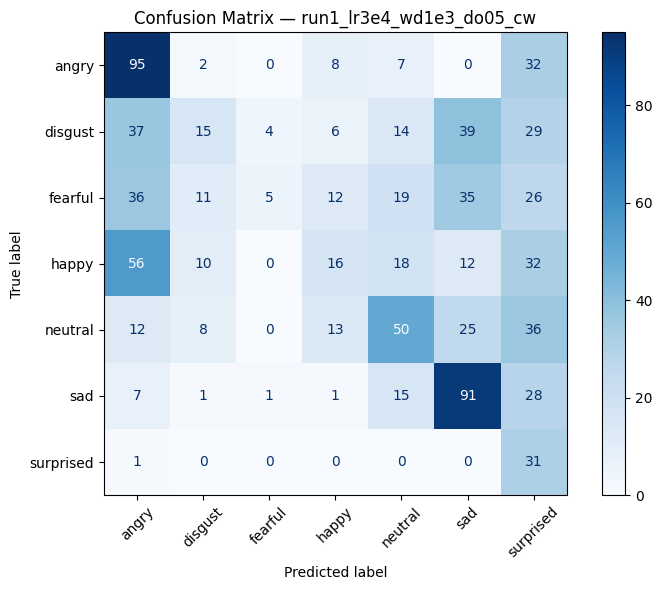

lr,████████▄▄▄▄▂▂▂▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▄▄▅▆▆▆▆▇▇▇██████
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▁▄▄▂█▇▇▆█▇▇▇▇▇▇█▇
val_loss,█▇▆▅▆▃▃▃▃▂▂▂▂▂▁▁▁▁
val_macro_f1,▁▂▄▅▄█▇▇▇██▇██▇███
lr,4e-05
test_acc,0.33817
test_macro_f1,0.28918



  INICIANDO: run2_lr5e4_wd1e3_do05_cw
  lr=0.0005  wd=0.001  dropout=0.5  class_weights=True



[21:08:34] Epoca 01/50 | Train loss 2.0464 acc 0.1622 | Val loss 1.8987 acc 0.2249 f1 0.1304 | lr 5.0e-04 | Time 6.1s


[21:08:41] Epoca 02/50 | Train loss 1.9102 acc 0.2149 | Val loss 1.8351 acc 0.2703 f1 0.1876 | lr 5.0e-04 | Time 7.4s


[21:08:47] Epoca 03/50 | Train loss 1.8228 acc 0.2542 | Val loss 1.8071 acc 0.3110 f1 0.2441 | lr 5.0e-04 | Time 6.3s


...

[21:10:15] Epoca 16/50 | Train loss 1.5891 acc 0.3669 | Val loss 1.6514 acc 0.3565 f1 0.3081 | lr 1.3e-04 | Time 6.7s
Early Stopping: 4/8 (best=0.3114)


[21:10:21] Epoca 17/50 | Train loss 1.5990 acc 0.3665 | Val loss 1.6257 acc 0.3493 f1 0.2998 | lr 1.3e-04 | Time 6.5s
Early Stopping: 5/8 (best=0.3114)


[21:10:27] Epoca 18/50 | Train loss 1.5837 acc 0.3704 | Val loss 1.6543 acc 0.3433 f1 0.2978 | lr 6.3e-05 | Time 6.1s
Early Stopping: 6/8 (best=0.3114)


[21:10:34] Epoca 19/50 | Train loss 1.5758 acc 0.3732 | Val loss 1.6390 acc 0.3493 f1 0.3034 | lr 6.3e-05 | Time 7.1s
Early Stopping: 7/8 (best=0.3114)


[21:10:40] Epoca 20/50 | Train loss 1.5750 acc 0.3770 | Val loss 1.6345 acc 0.3457 f1 0.3005 | lr 6.3e-05 | Time 5.8s
Early Stopping: 8/8 (best=0.3114)
Early stopping en epoch 20 (best val_f1=0.3114)

--- RESULTADO TEST [run2_lr5e4_wd1e3_do05_cw] ---
  best_epoch=12  best_val_f1=0.3114
  test_macro_f1=0.3161  test_acc=0.3650
              precision    recall  f1-score   support

       angry       0.48      0.72      0.58       144
     disgust       0.39      0.09      0.15       144
     fearful       0.57      0.03      0.05       144
       happy       0.27      0.19      0.22       144
     neutral       0.41      0.41      0.41       144
         sad       0.51      0.61      0.55       144
   surprised       0.14      1.00      0.25        32

    accuracy                           0.36       896
   macro avg       0.40      0.44      0.32       896
weighted avg       0.43      0.36      0.32       896



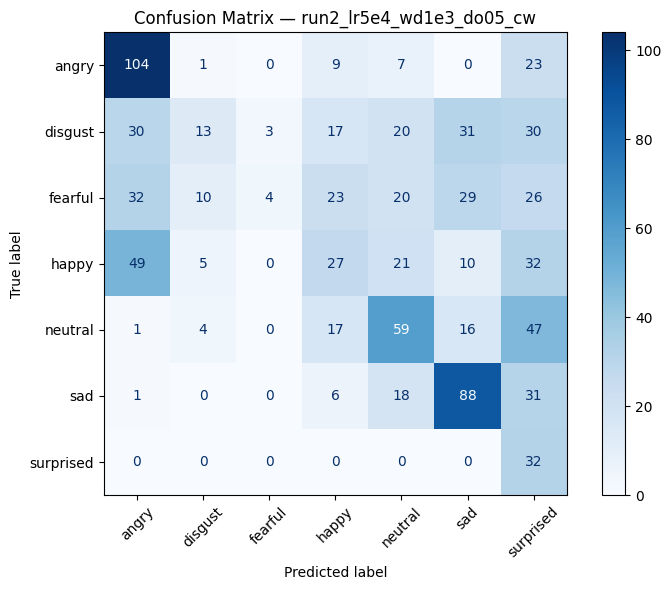

lr,████████▄▄▄▄▄▄▂▂▂▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▄▅▆▆▇▇▇▇▇▇████████
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▃▆▅▄▇▇▇▇█▇█▇▇▇██▇█▇
val_loss,█▆▆▅▄▃▂▃▂▂▂▂▂▂▂▂▁▂▁▁
val_macro_f1,▁▃▅▅▅▇▇▇▇█▇█▇████▇██
lr,6e-05
test_acc,0.36496
test_macro_f1,0.31614



  INICIANDO: run3_lr3e4_wd1e3_do03_cw
  lr=0.0003  wd=0.001  dropout=0.3  class_weights=True



[21:10:52] Epoca 01/50 | Train loss 2.0344 acc 0.1668 | Val loss 1.8968 acc 0.2261 f1 0.1202 | lr 3.0e-04 | Time 6.7s


[21:10:58] Epoca 02/50 | Train loss 1.9266 acc 0.2083 | Val loss 1.8741 acc 0.2440 f1 0.1769 | lr 3.0e-04 | Time 6.3s


[21:11:05] Epoca 03/50 | Train loss 1.8543 acc 0.2487 | Val loss 1.8053 acc 0.2919 f1 0.2224 | lr 3.0e-04 | Time 7.2s


...

[21:13:06] Epoca 21/50 | Train loss 1.6138 acc 0.3545 | Val loss 1.6546 acc 0.3397 f1 0.2967 | lr 3.7e-05 | Time 6.2s
Early Stopping: 4/8 (best=0.3115)


[21:13:13] Epoca 22/50 | Train loss 1.6112 acc 0.3525 | Val loss 1.6535 acc 0.3385 f1 0.2984 | lr 3.7e-05 | Time 7.2s
Early Stopping: 5/8 (best=0.3115)


[21:13:19] Epoca 23/50 | Train loss 1.6029 acc 0.3562 | Val loss 1.6466 acc 0.3433 f1 0.3009 | lr 1.9e-05 | Time 6.0s
Early Stopping: 6/8 (best=0.3115)


[21:13:27] Epoca 24/50 | Train loss 1.6053 acc 0.3604 | Val loss 1.6452 acc 0.3409 f1 0.2998 | lr 1.9e-05 | Time 7.6s
Early Stopping: 7/8 (best=0.3115)


[21:13:33] Epoca 25/50 | Train loss 1.6034 acc 0.3533 | Val loss 1.6468 acc 0.3397 f1 0.2987 | lr 1.9e-05 | Time 6.0s
Early Stopping: 8/8 (best=0.3115)
Early stopping en epoch 25 (best val_f1=0.3115)

--- RESULTADO TEST [run3_lr3e4_wd1e3_do03_cw] ---
  best_epoch=17  best_val_f1=0.3115
  test_macro_f1=0.3144  test_acc=0.3571
              precision    recall  f1-score   support

       angry       0.45      0.67      0.54       144
     disgust       0.36      0.14      0.20       144
     fearful       0.33      0.03      0.05       144
       happy       0.29      0.17      0.22       144
     neutral       0.45      0.36      0.40       144
         sad       0.47      0.63      0.54       144
   surprised       0.15      1.00      0.25        32

    accuracy                           0.36       896
   macro avg       0.36      0.43      0.31       896
weighted avg       0.38      0.36      0.32       896



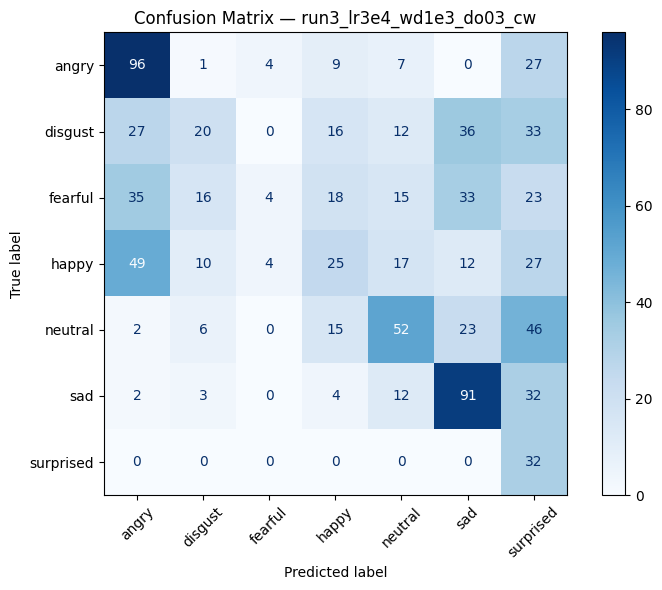

lr,█████████▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇██████████
train_loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
val_acc,▁▂▅▄▃▇▇▆▅▆▇▇▇▇▆▇█▇▇▇▇▇▇▇▇
val_loss,█▇▅▅▆▃▃▃▄▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁
val_macro_f1,▁▃▅▅▅▇█▇▆▇▇█▇█▆▇██▇█▇████
lr,2e-05
test_acc,0.35714
test_macro_f1,0.31442



  INICIANDO: run4_lr3e4_wd1e3_do05_nocw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=False



[21:13:45] Epoca 01/50 | Train loss 2.0608 acc 0.1690 | Val loss 1.8627 acc 0.2333 f1 0.1441 | lr 3.0e-04 | Time 7.5s


[21:13:52] Epoca 02/50 | Train loss 1.9481 acc 0.2072 | Val loss 1.8435 acc 0.2368 f1 0.1197 | lr 3.0e-04 | Time 6.3s
Early Stopping: 1/8 (best=0.1441)


[21:13:59] Epoca 03/50 | Train loss 1.8810 acc 0.2408 | Val loss 1.7834 acc 0.2727 f1 0.1633 | lr 3.0e-04 | Time 7.9s


...

[21:17:41] Epoca 34/50 | Train loss 1.5938 acc 0.3849 | Val loss 1.5951 acc 0.3864 f1 0.3430 | lr 3.7e-05 | Time 6.3s
Early Stopping: 4/8 (best=0.3496)


[21:17:48] Epoca 35/50 | Train loss 1.5949 acc 0.3789 | Val loss 1.5942 acc 0.3876 f1 0.3485 | lr 3.7e-05 | Time 7.1s
Early Stopping: 5/8 (best=0.3496)


[21:17:55] Epoca 36/50 | Train loss 1.5921 acc 0.3778 | Val loss 1.5959 acc 0.3852 f1 0.3436 | lr 1.9e-05 | Time 6.7s
Early Stopping: 6/8 (best=0.3496)


[21:18:01] Epoca 37/50 | Train loss 1.5852 acc 0.3849 | Val loss 1.5935 acc 0.3792 f1 0.3351 | lr 1.9e-05 | Time 6.3s
Early Stopping: 7/8 (best=0.3496)


[21:18:09] Epoca 38/50 | Train loss 1.5880 acc 0.3794 | Val loss 1.6003 acc 0.3816 f1 0.3383 | lr 1.9e-05 | Time 7.4s
Early Stopping: 8/8 (best=0.3496)
Early stopping en epoch 38 (best val_f1=0.3496)

--- RESULTADO TEST [run4_lr3e4_wd1e3_do05_nocw] ---
  best_epoch=30  best_val_f1=0.3496
  test_macro_f1=0.3754  test_acc=0.4163
              precision    recall  f1-score   support

       angry       0.40      0.78      0.53       144
     disgust       0.33      0.16      0.22       144
     fearful       0.44      0.05      0.09       144
       happy       0.32      0.26      0.29       144
     neutral       0.45      0.62      0.52       144
         sad       0.53      0.59      0.56       144
   surprised       0.34      0.56      0.42        32

    accuracy                           0.42       896
   macro avg       0.40      0.43      0.38       896
weighted avg       0.41      0.42      0.37       896



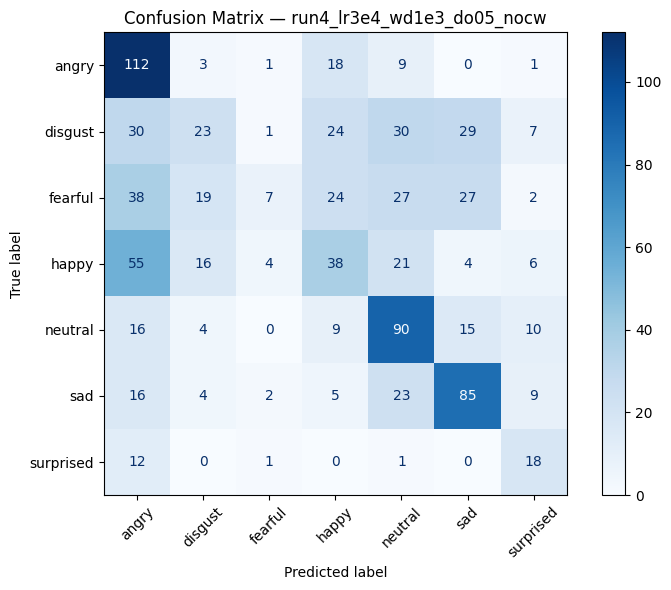

lr,██████████████████████▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,█▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▃▄▂▆▅▅▅▅▅▅▅▅▇▆▇▆▆▇▆▆▇▇▇▆▇▇▇█▇▇████▇█
val_loss,██▆▅▇▄▄▄▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
val_macro_f1,▂▁▂▄▃▅▅▅▅▆▆▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████▇██████
lr,2e-05
test_acc,0.41629
test_macro_f1,0.37537


In [45]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     True,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


### 5. Resumen de experimentos y evaluación final


In [19]:
# Tabla resumen de la experimentación -----------------------------------------------
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)



  RESUMEN FINAL DE EXPERIMENTOS
                  run_name  best_val_f1  best_epoch  test_macro_f1  test_acc
run4_lr3e4_wd1e3_do05_nocw       0.5386          41         0.5947    0.5792
  run2_lr5e4_wd1e3_do05_cw       0.5374          41         0.5831    0.5714
  run3_lr3e4_wd1e3_do03_cw       0.4763          47         0.5518    0.5513
  run1_lr3e4_wd1e3_do05_cw       0.4652          29         0.5394    0.5379


,run_name,best_val_f1,best_epoch,test_macro_f1,test_acc
0,run4_lr3e4_wd1e3_do05_nocw,0.5386,41,0.5947,0.5792
1,run2_lr5e4_wd1e3_do05_cw,0.5374,41,0.5831,0.5714
2,run3_lr3e4_wd1e3_do03_cw,0.4763,47,0.5518,0.5513
3,run1_lr3e4_wd1e3_do05_cw,0.4652,29,0.5394,0.5379
